# TP2 — Representación vectorial de texto: embeddings y búsqueda semántica

**Procesamiento del Lenguaje Natural — TUIA (FCEIA, UNR)**

Grupo: Sebastián Beltramo, Bautista Cortinas, Valentín Cura y Franco Maragliano.

Corpus: las 200 sinopsis de Lectulandia del TP1 (`data/libros.csv`), de las categorías
ciencia ficción, fantástico, terror e histórico.

**Cómo está organizado.** La lógica vive en módulos de `src/` que tienen sus propios tests
(`tests/test_tp2.py`). El notebook los llama y muestra los resultados. Así lo que se evalúa
es código probado, no celdas sueltas.

| Sección | Consigna |
|---|---|
| 0. Preparación | entorno, versiones, descargas |
| 1. Corpus y preprocesamiento | Parte A y "Primer análisis" |
| 2. Las cuatro preguntas sobre TF-IDF | "Primer análisis del corpus" |
| 3. Word2Vec propio contra SBW | Parte B |
| 4. Modelo de oración (SBERT) | Parte C |
| 5. Comparación y visualización | Parte D |
| 6. Evaluación con `queries.json` | Sección 5, el núcleo del TP |
| 7. Conclusiones | — |

**Credenciales.** Este notebook no usa ninguna. La cátedra habilitó trabajar desde el CSV
(sin Postgres ni Supabase), así que no hay conexión que configurar.

## 0. Preparación

En Colab, la celda siguiente clona el repositorio e instala lo que Colab no trae. Fuera de
Colab, hay que ejecutar el notebook desde la raíz del repositorio con las dependencias de
`requirements.txt` instaladas.

No se fija `numpy==1.23.5` (el pin del apunte de la Unidad 2): no convive con
sentence-transformers. gensim ≥ 4.3.3 funciona con el numpy que trae Colab.

In [1]:
import os, sys, subprocess
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules
REPO = "https://github.com/ValentinCura/NLP-C4-TUIA.git"
RAMA = "borrar"

if EN_COLAB:
    from importlib.metadata import version
    destino = Path("/content/NLP-C4-TUIA")
    if not destino.exists():
        subprocess.run(["git", "clone", "-q", "-b", RAMA, REPO, str(destino)], check=True)
    os.chdir(destino)
    numpy_antes = version("numpy")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "gensim>=4.3.3", "lingua-language-detector"], check=True)
    # Si pip cambió numpy y el kernel ya lo tenía cargado, seguir mezclaría dos
    # versiones en memoria: hay que reiniciar el entorno y volver a "Run all".
    if version("numpy") != numpy_antes and "numpy" in sys.modules:
        raise RuntimeError(f"pip cambió numpy ({numpy_antes} -> {version('numpy')}). "
                           "Reiniciar el entorno de ejecución y volver a ejecutar todo.")
    os.environ.setdefault("SBW_PATH", "/content/SBW-vectors-300-min5.bin.gz")

RAIZ = Path.cwd()
assert (RAIZ / "src" / "corpus.py").exists(), "Ejecutar desde la raíz del repositorio"
sys.path.insert(0, str(RAIZ / "src"))
try:
    COMMIT = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True,
                            text=True).stdout.strip() or "(sin git)"
except FileNotFoundError:          # git no instalado (fuera de Colab puede pasar)
    COMMIT = "(sin git)"
print(f"Repositorio en {RAIZ} | commit {COMMIT}")

# Las figuras se guardan además de mostrarse, para que queden como salida del TP.
DIR_FIG = RAIZ / "data" / "figuras"
DIR_FIG.mkdir(parents=True, exist_ok=True)

# El SBW (1,1 GB) no está en el repositorio: se descarga una vez.
RUTA_SBW = Path(os.environ.get("SBW_PATH", RAIZ.parent / "SBW-vectors-300-min5.bin.gz"))
os.environ["SBW_PATH"] = str(RUTA_SBW)        # embeddings.py lo lee al importarse
if not RUTA_SBW.exists():
    import urllib.request
    print("Descargando SBW-vectors-300-min5 (~1,1 GB)...")
    urllib.request.urlretrieve(
        "https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz",
        RUTA_SBW)
print(f"SBW: {RUTA_SBW} ({RUTA_SBW.stat().st_size / 1e9:.2f} GB)")

Repositorio en /work | commit (sin git)
SBW: /parent/SBW-vectors-300-min5.bin.gz (1.12 GB)


In [2]:
import platform, warnings
import numpy as np, pandas as pd, sklearn, gensim, torch, sentence_transformers
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

SEMILLA = 42   # la única semilla del notebook; los módulos reciben esta misma
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

print(f"Python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__}")
print(f"scikit-learn {sklearn.__version__} | gensim {gensim.__version__} | "
      f"sentence-transformers {sentence_transformers.__version__} | torch {torch.__version__}")

/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python 3.12.15 | numpy 2.5.3 | pandas 2.3.3
scikit-learn 1.9.1 | gensim 4.4.0 | sentence-transformers 6.1.0 | torch 2.14.1+cpu


## 1. Corpus y preprocesamiento (Parte A)

Se traen los documentos desde el CSV, como habilitó la cátedra. `corpus.py` puede leer
igual desde PostgreSQL (`fuente="postgres"`) y devuelve exactamente lo mismo.

**Dos versiones del texto.** La regla del proyecto es que **el corpus guarda solo el texto
crudo, y el preprocesamiento pertenece al modelo**:

- **TF-IDF y los promedios de word vectors** reciben texto *tokenizado*: minúsculas, sin
  stopwords, sin puntuación, palabras de 3 o más letras. Para una bolsa de palabras eso
  colapsa variantes y saca ruido.
- **SBERT** recibe el texto *crudo*. Fue entrenado sobre texto natural, usa el orden y las
  palabras funcionales y tiene su propio tokenizador de subpalabras. Si le damos el texto
  "limpio" para TF-IDF lo sacamos de dominio.

Por eso `Documento` no tiene un campo `tokens`: no existe *la* tokenización, existe la que
quiere cada modelo.

In [3]:
import corpus
import preprocesamiento as pp

docs = corpus.traer_documentos()                 # desde data/libros.csv
ids = np.array([d.id for d in docs])
titulos = [d.titulo for d in docs]
crudos = [d.texto for d in docs]                 # título + sinopsis, sin tocar
tokenizados = [pp.tokenizar(t) for t in crudos]  # la versión de TF-IDF

n_crudo = sum(len(t.split()) for t in crudos)
n_tok = sum(len(t) for t in tokenizados)
print(f"{len(docs)} documentos | {n_crudo:,} palabras crudas -> {n_tok:,} tokens "
      f"({n_tok / n_crudo:.0%} sobrevive al preprocesamiento)")
corpus.a_dataframe(docs)[["id", "titulo", "generos", "categoria_origen", "serie"]].head()

200 documentos | 31,208 palabras crudas -> 14,183 tokens (45% sobrevive al preprocesamiento)


,id,titulo,generos,categoria_origen,serie
0,123171,Extraños eones,"[Fantástico, Intriga, Novela, Terror]",[terror],None
1,123236,Las cosas más delicadas,"[Novela, Terror]",[terror],None
2,123251,Las abandonadas,"[Novela, Terror]",[terror],None
3,123734,Esa maldita voz y otros relatos fantasmagóricos,"[Otros, Relato, Terror]",[terror],None
4,123757,El Monte de las Ánimas y otras leyendas góticas,"[Fantástico, Otros, Relato, Terror]",[terror],None


In [4]:
d = docs[1]
print("CRUDO     :", d.texto[:300], "...\n")
print("TOKENIZADO:", pp.tokenizar(d.texto)[:40])

CRUDO     : Las cosas más delicadas. Su arte te dejará sin aliento. En las sombras del Nueva York de los años 50, una mente brillante se tambalea al borde de la locura. Las esculturas de Edgar Maguire están arrasando en el mundo del arte, pero detrás de cada obra maestra se esconde un horrible secreto. Cuando F ...

TOKENIZADO: ['cosas', 'delicadas', 'arte', 'dejará', 'aliento', 'sombras', 'york', 'años', 'mente', 'brillante', 'tambalea', 'borde', 'locura', 'esculturas', 'edgar', 'maguire', 'arrasando', 'mundo', 'arte', 'obra', 'maestra', 'esconde', 'horrible', 'secreto', 'fiona', 'objeto', 'obsesión', 'vida', 'edgar', 'vuelve', 'entrar', 'vida', 'enciende', 'pasión', 'difumina', 'límites', 'creación', 'destrucción', 'medida', 'arte']


### Cada decisión de preprocesamiento es una pérdida de información deliberada

| Decisión | Qué se pierde | TF-IDF / word vectors | SBERT |
|---|---|---|---|
| Minúsculas | entidades nombradas (`Madrid`/`madrid`), inicio de oración | **sí**: si no, `El` y `el` son dos dimensiones | **no**: el modelo es *cased* |
| Quitar acentos | `si`/`sí`, `el`/`él`, `papa`/`papá` | **no**: en castellano las tildes distinguen palabras | **no** |
| Quitar puntuación | límites de oración | **sí**: en una bolsa no hay oraciones | **no** |
| Quitar stopwords | negaciones y relaciones sintácticas | **sí**: tienen IDF casi nulo de todas formas | **no**: el orden y las palabras funcionales son señal |

La celda siguiente muestra la pérdida en vez de afirmarla.

In [5]:
for frase in ["Él no es un thriller: es terror.",
              "Es un thriller, no terror.",
              "Madrid, sí; el papá de Él."]:
    print(f"{frase:<34} -> {pp.tokenizar(frase)}")

Él no es un thriller: es terror.   -> ['thriller', 'terror']
Es un thriller, no terror.         -> ['thriller', 'terror']
Madrid, sí; el papá de Él.         -> ['madrid', 'papá']


Las dos primeras frases dicen lo contrario y quedan casi iguales: la negación desapareció.
En la tercera, *sí* y *él* se pierden por ser stopwords, y *Madrid* pasa a minúscula.
Para buscar "de qué trata" un libro eso es aceptable. Para algo sensible a la polaridad, como
un análisis de sentimiento, no lo es.

## 2. Primer análisis: las cuatro preguntas sobre TF-IDF

Las cuatro preguntas se responden **midiendo** sobre el corpus, no razonando. El código está
en `src/experimentos.py`; cada función imprime su diseño, sus números y una lectura que se
calcula de esos números.

### Pregunta 1 — ¿Cuántas sinopsis hacen falta para que TF-IDF sea estable?

Se fijan 20 documentos *sonda* y se varía solo el corpus de *fondo* que define el IDF
(`fit` sobre el fondo, `transform` sobre las sondas), con 30 réplicas por tamaño. Se mide el
Jaccard de los 10 términos principales entre réplicas. Se usa el **corpus ampliado** (1700
sinopsis de las mismas categorías, scrapeado aparte): con 200 la curva se corta enseguida y
las réplicas comparten casi los mismos documentos.

In [6]:
import experimentos
docs_ampliado = corpus.traer_documentos(tabla="libros_ampliado")
curva = experimentos.experimento_estabilidad(docs_ampliado, semilla=SEMILLA)


PREGUNTA 1 - Estabilidad de TF-IDF segun el tamano del corpus



Diseno del experimento
  20 documentos SONDA, fijos en todas las replicas
  el corpus de FONDO varia: [10, 25, 50, 100, 150, 300, 600, 1200]
  30 replicas por tamano, top-10 terminos por documento
  metrica: Jaccard promedio entre pares de replicas

  Lo que varia es SOLO el IDF. Si se resamplearan tambien los
  documentos medidos, se mezclarian dos fuentes de variacion y el
  resultado no significaria nada.



  fondo   Jaccard@10   Jaccard@3   estable?    solape
  ------------------------------------------------------
     10        0.230       0.152         no       1%   
     25        0.233       0.253         no       1%   +0.003
     50        0.249       0.319         no       3%   +0.016
    100        0.284       0.396         no       6%   +0.035
    150        0.311       0.442         no       9%   +0.027
    300        0.371       0.512         no      18%   +0.060
    600        0.444       0.556         no      36%   +0.073
   1200        0.620       0.658         no      71%   +0.176

LECTURA DEL RESULTADO
  Con 10 documentos de fondo, dos muestras distintas
  coinciden en 23% de los terminos caracteristicos.
  Con 1200, en 62%.

  La curva NO se aplano dentro del rango medido (ultimo salto
  +0.176, umbral 0.02). Con este corpus no
  alcanza para afirmar que TF-IDF se estabilizo: haria falta
  seguir la curva con mas documentos.

  Por que cuesta tanto estabilizarse: el 51%

### Pregunta 2 — ¿Qué sesgo introduce que las sinopsis sean texto promocional?

In [7]:
_ = experimentos.experimento_promocional(docs, semilla=SEMILLA)


PREGUNTA 2 - El sesgo del texto promocional



1. Presencia en los terminos caracteristicos
   De los 2000 terminos top-10 de las 200 sinopsis,
   16 son vocabulario promocional (0.8%).
   Los mas frecuentes: ['edición', 'autor', 'aliento', 'novela', 'premio', 'trilogía', 'obra', 'trepidante']

   Es un porcentaje BAJO, y tiene una explicacion que conviene
   entender: TF-IDF penaliza justamente lo que aparece en todos los
   documentos. Como las sinopsis son TODAS promocionales, esas
   palabras tienen IDF bajo y quedan relegadas. O sea que TF-IDF
   ya filtra parte del sesgo por construccion.

2. El registro publicitario, predice el genero?
   Informacion mutua entre cada termino promocional y cada genero.
   Si diera cero, el vocabulario promocional seria ruido inocuo.



   genero              termino promo mas informativo         IM  IM media
   --------------------------------------------------------------------
   Juvenil             novela                            0.0931    0.0146
   Novela              magistral                         0.0916    0.0134
   Histórico           sorprenderá                       0.0895    0.0159
   Terror              éxito                             0.0856    0.0173
   Relato              magistral                         0.0730    0.0128
   Romántico           descubre                          0.0688    0.0090
   Ciencia ficción     jamás                             0.0575    0.0157
   Fantástico          brillante                         0.0423    0.0109

3. Que pasa si se le quita el vocabulario promocional al modelo
   Se quitan 37 terminos del vocabulario (11 con tilde, p. ej. ['clásico', 'crítica', 'dejará', 'edición']).


   con vocabulario promocional      f1 micro 0.780 (+-0.024)  f1 macro 0.690 (+-0.032)
   sin vocabulario promocional      f1 micro 0.781 (+-0.024)  f1 macro 0.691 (+-0.036)

   Diferencia pareada en f1 micro (con - sin), 20 splits:
     media -0.000 | desvio 0.009 | rango [-0.017, +0.022]
     el vocabulario promocional ayuda en 9 splits, perjudica en 10 y empata en 1
   La diferencia media es menor que su propio desvio entre
   splits: con 200 libros no se puede distinguir de cero.

RESPUESTA A LA PREGUNTA
  El sesgo existe pero no es el que uno esperaria. Las palabras
  publicitarias no dominan los terminos caracteristicos, porque
  TF-IDF ya las castiga por aparecer en todas las sinopsis.

  El sesgo real es mas sutil y esta en otro lado:
   - Una sinopsis NO DESCRIBE el libro: selecciona lo vendible.
     Omite el final, exagera el conflicto y destaca lo que se
     parece a otros exitos. El clasificador aprende de que trata
     LA CAMPANA, no de que trata el libro.
   - Cada gen

### Pregunta 3 — ¿Cómo cambia la evaluación en multi-etiqueta?

In [8]:
_ = experimentos.experimento_multietiqueta(docs, semilla=SEMILLA)


PREGUNTA 3 - Evaluacion multi-etiqueta contra multi-clase

Por que este problema NO PUEDE ser multi-clase
  etiquetas por libro: minimo 2, promedio 2.83, maximo 6
  No hay un solo libro con un unico genero. Forzar multi-clase
  obligaria a descartar etiquetas reales o a inventar una clase
  por cada combinacion observada, que serian decenas con pocos
  ejemplos cada una.

Distribucion de las 27 etiquetas
  Novela                170  (  85% de los libros)
  Fantástico             69  (  34% de los libros)
  Terror                 54  (  27% de los libros)
  Histórico              52  (  26% de los libros)
  Ciencia ficción        50  (  25% de los libros)
  Juvenil                43  (  22% de los libros)
  ... 13 generos con menos de 5 libros: no se pueden
  aprender NI estratificar en un split.

  Se trabaja con los 10 generos con >= 10 libros: ['Aventuras', 'Ciencia ficción', 'Fantástico', 'Histórico', 'Intriga', 'Juvenil', 'Novela', 'Relato', 'Romántico', 'Terror']

  entrenamiento

### Pregunta 4 — ¿Qué pasa con los libros en gallego o catalán?

In [9]:
_ = experimentos.experimento_idioma(docs)


PREGUNTA 4 - Deteccion de idioma

LIMITACION DEL INSTRUMENTO, antes de mirar ningun resultado:
  lingua soporta 75 idiomas, entre ellos el catalan, pero NO tiene
  modelo de GALLEGO. Una sinopsis en gallego no puede ser detectada
  como tal: va a caer en portugues o en castellano, sus parientes
  mas cercanos. La pregunta de la consigna no se puede responder
  del todo con esta herramienta, y conviene decirlo en vez de
  reportar 'cero libros en gallego' como si fuera un hallazgo.



Idioma detectado en 200 sinopsis:
  SPANISH       200  (100.0%)

Confianza de la deteccion:
  mediana 1.000  |  minima 0.998  |  maxima 1.000
  sinopsis con confianza < 0.90: 0 de 200

No detectadas como castellano: 0

CONTROL DEL INSTRUMENTO
  Tres traducciones del mismo parrafo. Si el detector no reconoce
  estas, el resultado de arriba no prueba nada.
  OK   castellano  detectado como SPANISH (0.97), segunda opcion PORTUGUESE 0.01
  OK   catalan     detectado como CATALAN (1.00), segunda opcion ITALIAN 0.00
  !!!  gallego     detectado como PORTUGUESE (0.91), segunda opcion SPANISH 0.04
  El catalan se reconoce. El gallego no puede: no esta en el
  repertorio, asi que cae en la lengua mas parecida SIN avisar.

SEGUNDO INSTRUMENTO: marcadores lexicos del gallego
  Palabras funcionales que existen en gallego y no en castellano
  (aínda, coa, coas, cos, cun, cunha, dous, dun, dunha, dunhas...). Se marca una
  sinopsis si aparecen 3 o mas marcadores distintos.
  Sinopsis marcadas: 1
  

El experimento afirma que, para TF-IDF, las palabras gallegas reciben IDF alto y pasan a
ser "términos característicos". Lo verificamos en vez de suponerlo:

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec_tmp = TfidfVectorizer()
m_tmp = vec_tmp.fit_transform(pp.para_sklearn(crudos))
fila = list(ids).index(124205)
pesos = m_tmp[fila].toarray().ravel()
top = pesos.argsort()[::-1][:12]
voc = vec_tmp.get_feature_names_out()
gallegas = experimentos.MARCADORES_GALLEGO
print("Top-12 TF-IDF de 'Morning Star':")
print([f"{voc[j]}{' (gl)' if voc[j] in gallegas else ''}" for j in top])

Top-12 TF-IDF de 'Morning Star':
['dun (gl)', 'dunha (gl)', 'coma', 'cantan', 'progresista', 'can', 'grilos', 'anamán', 'procurando', 'paixóns', 'tesouro', 'bandoleiros']


## 3. Word2Vec / FastText propio contra SBW pre-entrenado (Parte B)

### Parámetros del modelo propio

| Parámetro | Valor | Por qué |
|---|---|---|
| `vector_size` | 100 | El SBW usa 300 porque tiene ~1400 millones de palabras para estimarlas. Con ~120 mil tokens, 300 dimensiones son más parámetros de los que los datos sostienen. |
| `window` | 5 | Punto medio: ventanas chicas (2-3) capturan sintaxis; grandes (10) capturan tema. |
| `min_count` | 3 | El default (5) dejaría afuera demasiado vocabulario en un corpus chico; menos de 3 da vectores de ruido. |
| `sg` | 1 (skip-gram) | Anda mejor que CBOW con corpus chicos y palabras poco frecuentes. |
| `epochs` | 30 | Con pocos datos hacen falta más pasadas para converger. |
| `workers`, `seed` | 1, 42 | Con un solo hilo el entrenamiento es **reproducible** byte a byte (con varios hilos no lo es). |

**Corpus de entrenamiento.** Se entrena sobre el corpus ampliado (1700 sinopsis), no sobre
las 200: con `min_count=3` el modelo de 200 sabría unas 500 palabras. **Hay que tenerlo en
cuenta:** el ampliado contiene a los 200 libros evaluados. Para un modelo no supervisado
es aceptable, pero significa que el modelo propio vio esos textos, incluidos sus nombres
propios.

**Qué optimiza el modelo (negative sampling).** Skip-gram aprende a predecir las palabras
del contexto a partir de la central. Hacerlo con un softmax sobre todo el vocabulario
obliga, en cada paso, a calcular un puntaje para *cada* palabra del vocabulario
(O(V) por ejemplo). Con millones de pasos es inviable. *Negative sampling* lo convierte en
una clasificación binaria: distinguir el par (palabra, contexto real) de unos pocos pares
con palabras sorteadas al azar ("negativas"). El costo pasa a O(k), con k ≈ 5. gensim usa
esa variante por defecto (`negative=5`, `hs=0`), como se ve abajo.

In [11]:
import embeddings

print("Parámetros:", embeddings.PARAMETROS)
modelos = embeddings.entrenar("libros_ampliado")
w2v, ft = modelos["word2vec"].wv, modelos["fasttext"].wv
print(f"\nnegative={modelos['word2vec'].negative}, hs={modelos['word2vec'].hs}")

Parámetros: {'vector_size': 100, 'window': 5, 'min_count': 3, 'sg': 1, 'epochs': 30, 'workers': 1, 'seed': 42}



Corpus de entrenamiento: tabla 'libros_ampliado'
  1700 documentos | 118,962 tokens | 26,384 palabras distintas

Parametros: vector_size=100, window=5, min_count=3, sg=1, epochs=30, workers=1, seed=42



  word2vec   vocabulario aprendido: 8,617 palabras (33% del corpus)



  fasttext   vocabulario aprendido: 8,617 palabras (33% del corpus)

  Las palabras descartadas son las que aparecen menos de 3 veces.
  FastText igual puede vectorizarlas, porque compone el vector a
  partir de n-gramas de caracteres. Word2Vec no: para el, una
  palabra fuera del vocabulario simplemente no existe.
  guardado: data/modelos/word2vec_libros_ampliado.model


  guardado: data/modelos/fasttext_libros_ampliado.model

negative=5, hs=0


In [12]:
sbw = embeddings.cargar_sbw()
print(f"SBW: {len(sbw):,} palabras (las más frecuentes), dimensión {sbw.vector_size}")
embeddings._cobertura(modelos["word2vec"], sbw)


Cargando SBW (limite: 400,000 palabras mas frecuentes)...


  400,000 vectores de 300 dimensiones
SBW: 400,000 palabras (las más frecuentes), dimensión 300

  Cobertura: el SBW recortado a 400,000 palabras contiene 7,710 de
  las 8,617 de nuestro modelo (89.5%). Las que faltan son
  nombres propios y terminos muy especificos del dominio.


### Vecinos más cercanos, lado a lado

Ocho palabras del dominio, frecuentes en el corpus (si no, el modelo propio ni las tendría).

In [13]:
def vecinos(kv, palabra, n=6):
    if kv is ft or palabra in kv:          # FastText compone palabras que no vio
        return ", ".join(p for p, _ in kv.most_similar(palabra, topn=n))
    return "(fuera de vocabulario)"

tabla_vecinos = pd.DataFrame(
    {"Word2Vec propio": [vecinos(w2v, p) for p in embeddings.PALABRAS_DOMINIO],
     "FastText propio": [vecinos(ft, p) for p in embeddings.PALABRAS_DOMINIO],
     "SBW pre-entrenado": [vecinos(sbw, p) for p in embeddings.PALABRAS_DOMINIO]},
    index=embeddings.PALABRAS_DOMINIO)
with pd.option_context("display.max_colwidth", 70):
    display(tabla_vecinos)

,Word2Vec propio,FastText propio,SBW pre-entrenado
guerra,"mundial, civil, cruento, designio, alemanes, avecina","posguerra, guerrera, guerras, aferra, mundial, guerrero","Guerra, guerras, francoprusiana, bélica, batalla, cruenta"
amor,"prohibido, enseña, redención, hannah, sienten, amistad","amo, amora, amorosa, rumor, amour, temor","desamor, amar, ternura, pasión, amada, amorosa"
muerte,"staunton, pertrechado, cirrosis, alcohólica, camarada, rescatado","muertes, muerto, muerta, fuerte, suerte, muertos","fallecimiento, asesinato, morir, muriera, murió, muerto"
magia,"ivy, mensual, envolvente, amora, primordial, acompañadas","maga, mafia, mago, ivy, magos, magnus","mágico, mago, hechizos, mágicas, magos, mágicos"
nave,"fiat, lux, espacial, nam, siderales, disparos","navío, naves, astronave, nam, tripulada, grave","naves, astronave, WhiteKnightTwo, crucero, Nave, tripulación"
vampiro,"sarren, creador, ewers, recrean, inmortal, beber","vampira, vampirismo, vampiros, zorro, jing, ramiro","vampiros, vampira, Drácula, vampiresa, licántropo, Lestat"
asesino,"rebeca, compañero, acechaba, atrapar, trate, boone","asesinó, asesinato, asesinos, asesinar, asesina, asesinatos","homicida, psicópata, asesina, asesinos, violador, pistolero"
rey,"micenas, católico, empuñar, sucesor, ramiro, jing","reclama, revés, recompensa, reyes, redka, red","monarca, reyes, reino, príncipe, reina, regente"


In [14]:
embeddings._medir_parentesco_formal(modelos, sbw, embeddings.PALABRAS_DOMINIO)


  PARENTESCO FORMAL de los vecinos
  Fraccion de los top-10 que comparten 4 letras iniciales con la
  palabra consultada. Alto = el modelo responde a la forma escrita;
  bajo = responde al significado.

  modelo                  formales   total   fraccion
  ---------------------------------------------------
  word2vec propio                1      80        1%
  fasttext propio               31      80       39%


  SBW pre-entrenado             14      80       18%


**Cómo leerlo.** Los tres modelos fallan de forma distinta:

- **Word2Vec propio** responde a la *coocurrencia* en este corpus chico. Por eso devuelve
  nombres de personajes y palabras que aparecen juntas en pocas sinopsis: memoriza libros
  concretos más que significados.
- **FastText propio** responde a la *forma escrita*: compone los vectores con n-gramas de
  caracteres, y por eso aparecen variantes morfológicas (útil) y palabras que solo se
  parecen en las letras (ruido). La fracción de "parentesco formal" lo cuantifica.
- **SBW** da vecinos semánticos generales: sinónimos y variantes legítimas, entrenado en
  noticias y Wikipedia, sin saber nada del registro de contratapa.

### El vector de documento: promedio de word vectors

Se arma promediando los vectores de las palabras del documento que el modelo conoce
(`embeddings.vector_promedio`). Las palabras fuera de vocabulario se ignoran. Si no queda
ninguna, el vector es **nulo** a propósito (no NaN, no un vector inventado), y después se
cuenta y no se normaliza (`vectores.normalizar_l2`).

**Qué se pierde al promediar**, además del orden:

In [15]:
def prom(frase):                          # sin quitar stopwords, para ver el efecto
    return embeddings.vector_promedio(frase.lower().split(), sbw)

def cos(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

pares = [("el perro muerde al hombre", "el hombre muerde al perro"),
         ("es una novela de terror", "no es una novela de terror"),
         ("un detective investiga un asesinato",
          "un asesino investiga a un detective")]
for a, b in pares:
    print(f"{cos(prom(a), prom(b)):.3f}  «{a}» vs «{b}»")

1.000  «el perro muerde al hombre» vs «el hombre muerde al perro»
0.986  «es una novela de terror» vs «no es una novela de terror»
0.956  «un detective investiga un asesinato» vs «un asesino investiga a un detective»


- **Orden y sintaxis**: quién hace qué a quién. Las dos primeras frases tienen similitud
  exactamente 1,0, porque el promedio de un conjunto no depende del orden.
- **Negación y composición**: agregar *no* mueve el promedio apenas una palabra de seis.
  Ninguna operación conmutativa puede expresar que una palabra modifica a otra.
- **Dilución**: en un texto largo las direcciones particulares se cancelan y el vector
  tiende al centroide del corpus. Los documentos se parecen entre sí por ser largos.
- **Peso de cada palabra**: todas pesan igual, salvo que se pondere (por ejemplo, por IDF).

**Por qué se usa igual:** no requiere entrenamiento adicional, cuesta O(n), no tiene
hiperparámetros y es la línea base honesta contra la que se mide algo más sofisticado.

In [16]:
import busqueda, vectores
import evaluacion as ev

reps = {}
reps["tfidf"] = busqueda.tfidf_tp1(crudos)
reps["tfidf_char"] = busqueda.tfidf_caracteres(crudos)
reps["w2v"] = busqueda.promedio_palabras("Word2Vec propio (promedio)", w2v, crudos)
reps["ft"] = busqueda.promedio_palabras("FastText propio (promedio)", ft, crudos)
reps["sbw"] = busqueda.promedio_palabras("SBW pre-entrenado (promedio)", sbw, crudos)

## 4. Modelo de oración: SBERT (Parte C)

Se usa `distiluse-base-multilingual-cased-v1`, el de la Unidad 2: multilingüe (cubre el
castellano), *cased* y entrenado para que oraciones con el mismo significado queden
cerca. Recibe el **texto crudo**.

In [17]:
sb = busqueda.cargar_sbert()
trunc = busqueda.analizar_truncamiento(sb, crudos)
print(f"Dimensión del embedding : {busqueda.dimension_sbert(sb)}")
print(f"Límite de tokens        : {sb.max_seq_length} (max_seq_length del modelo)")
print(f"Posiciones del encoder  : {sb[0].auto_model.config.max_position_embeddings} "
      f"(el transformer admitiría más; el modelo de oración fue configurado en 128)")
print(f"\nDocumentos truncados    : {trunc['truncados']} de {trunc['documentos']} "
      f"({trunc['fraccion_truncados']:.0%})")
print(f"Tokens por documento    : mediana {trunc['tokens_mediana']:.0f}, "
      f"máximo {trunc['tokens_max']}")
print(f"De los truncados se pierde, en promedio, el "
      f"{trunc['fraccion_texto_perdida_media']:.0%} del texto")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:  21%|██        | 21/100 [00:00<00:00, 209.83it/s]

Loading weights:  53%|█████▎    | 53/100 [00:00<00:00, 253.72it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 344.97it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (350 > 128). Running this sequence through the model will result in indexing errors


Dimensión del embedding : 512
Límite de tokens        : 128 (max_seq_length del modelo)
Posiciones del encoder  : 512 (el transformer admitiría más; el modelo de oración fue configurado en 128)

Documentos truncados    : 172 de 200 (86%)
Tokens por documento    : mediana 225, máximo 572
De los truncados se pierde, en promedio, el 44% del texto


**El modelo no avisa que trunca.** `encode()` corta en silencio todo lo que pase de
`max_seq_length` *tokens de subpalabra* (contando `[CLS]` y `[SEP]`), y el embedding
representa solo el principio del texto. Por eso el conteo se hace con el **tokenizador del
modelo**, no con caracteres ni palabras. La celda siguiente muestra cuánto se equivocaría
contar palabras.

Subpalabras por palabra: mediana 1.52
Si se contaran PALABRAS (> 128): 118 truncados
Contando TOKENS reales:                172 truncados


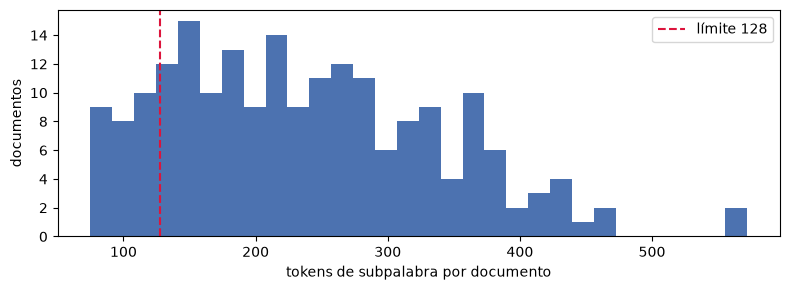

In [18]:
palabras = np.array([len(t.split()) for t in crudos])
largos = trunc["largos"]
print(f"Subpalabras por palabra: mediana {np.median(largos / palabras):.2f}")
print(f"Si se contaran PALABRAS (> {sb.max_seq_length}): "
      f"{int((palabras > sb.max_seq_length).sum())} truncados")
print(f"Contando TOKENS reales:                {trunc['truncados']} truncados")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(largos, bins=30, color="#4C72B0")
ax.axvline(sb.max_seq_length, color="crimson", ls="--",
           label=f"límite {sb.max_seq_length}")
ax.set_xlabel("tokens de subpalabra por documento"); ax.set_ylabel("documentos")
ax.legend(); plt.tight_layout()
plt.savefig(DIR_FIG / "sbert_truncamiento.png", dpi=120); plt.show()

Como la mayoría de las sinopsis se trunca, se agrega una variante **por fragmentos**: el
texto se parte en grupos de oraciones completas que entran en 128 tokens, se codifica
cada fragmento y se promedian. No es lo que pide la consigna, es un **control**: si
rinde igual que la versión truncada, el principio de la sinopsis alcanzaba.

In [19]:
reps["sbert"] = busqueda.sbert(crudos, sb)
reps["sbert_frag"] = busqueda.sbert_fragmentos(crudos, sb)
print(reps["sbert_frag"].info)

{'fragmentos_media': 2.595, 'fragmentos_max': 6, 'dimension': 512, 'documentos_nulos': 0, 'filas_nulas': []}


### Validación de todas las representaciones

Antes de comparar nada: dimensión, NaN, infinitos, vectores nulos y normalización. La
validación está en `vectores.validar` y la aplican todas las representaciones al
construirse (una matriz con NaN o infinitos no llega a esta celda: lanza una excepción).

In [20]:
filas = []
for clave, rep in reps.items():
    m = rep.matriz
    filas.append({"representación": rep.nombre, "familia": rep.familia,
                  "documentos": m.shape[0], "dimensión": m.shape[1],
                  "NaN": int(np.isnan(m).sum()), "Inf": int(np.isinf(m).sum()),
                  "vectores nulos": rep.info["documentos_nulos"],
                  "normalizada": vectores.esta_normalizada(m),
                  "cobertura media": rep.info.get("cobertura_media", np.nan)})
pd.DataFrame(filas)

,representación,familia,documentos,dimensión,NaN,Inf,vectores nulos,normalizada,cobertura media
0,TF-IDF (TP1),lexica,200,6898,0,0,0,True,NaN
1,TF-IDF n-gramas de caracteres,lexica,200,23283,0,0,0,True,NaN
2,Word2Vec propio (promedio),promedio de palabras,200,100,0,0,0,True,0.812347
3,FastText propio (promedio),promedio de palabras,200,100,0,0,0,True,1.000000
4,SBW pre-entrenado (promedio),promedio de palabras,200,300,0,0,0,True,0.906167
5,SBERT (truncado),oracion,200,512,0,0,0,True,NaN
6,SBERT (por fragmentos),oracion,200,512,0,0,0,True,NaN


In [21]:
# Los embeddings se guardan en disco además de calcularse: recalcularlos cuesta minutos.
DIR_EMB = RAIZ / "data" / "embeddings"
DIR_EMB.mkdir(parents=True, exist_ok=True)
np.save(DIR_EMB / "ids.npy", ids)
for clave, rep in reps.items():
    np.save(DIR_EMB / f"{clave}.npy", rep.matriz)
print(sorted(p.name for p in DIR_EMB.glob("*.npy")))

['ft.npy', 'ids.npy', 'sbert.npy', 'sbert_frag.npy', 'sbw.npy', 'tfidf.npy', 'tfidf_char.npy', 'w2v.npy']


## 5. Comparación y visualización (Parte D)

Se usan **las mismas consultas** que en la evaluación (sección 6), cargadas del conjunto de
evaluación.

In [22]:
RUTA_CONSULTAS = RAIZ / "queries.json"
if not RUTA_CONSULTAS.exists():
    RUTA_CONSULTAS = RAIZ / "queries_propuesta.json"
consultas, estado = ev.cargar_consultas(RUTA_CONSULTAS, ids,
                                        {d.id: d.generos for d in docs})
por_id = {c.id: c for c in consultas}
print(f"{RUTA_CONSULTAS.name}: {len(consultas)} consultas")
print(f"ESTADO: {estado}")
if "PROVISIONAL" in estado.upper():
    print("\n*** ATENCION: conjunto de evaluacion PROVISIONAL. Los numeros de las "
          "secciones 5 y 6 no son definitivos. ***")

queries_propuesta.json: 16 consultas
ESTADO: PROVISIONAL - PENDIENTE DE VALIDACION DEL GRUPO. No usar para conclusiones academicas.

*** ATENCION: conjunto de evaluacion PROVISIONAL. Los numeros de las secciones 5 y 6 no son definitivos. ***


### Rankings lado a lado

Top-5 de cada representación para tres consultas en lenguaje natural. ✓ marca los libros
que el conjunto de evaluación considera relevantes; entre paréntesis va la similitud coseno.

**Ojo con los 0,00 de TF-IDF:** son empates. Esos documentos no comparten ninguna palabra
con la consulta, y el orden en que aparecen es el del CSV, no un ranking. La evaluación de
la sección 6 trata esos empates como corresponde.

In [23]:
principales = [reps[k] for k in ["tfidf", "w2v", "sbw", "sbert"]]
pos = {i: n for n, i in enumerate(ids)}
for qid in ["q03", "q07", "q13"]:
    c = por_id[qid]
    print(f"\n{qid} — «{c.texto}»  ({len(c.relevantes)} relevantes)")
    with pd.option_context("display.max_colwidth", 48):
        display(busqueda.lado_a_lado(principales, c.texto, titulos,
                                     {pos[i] for i in c.relevantes}, k=5))


q03 — «historias de viajes en el tiempo»  (5 relevantes)


,TF-IDF (TP1),Word2Vec propio (promedio),SBW pre-entrenado (promedio),SBERT (truncado)
1,Realidades a medida (0.14),La llamada de Cthulhu (Ilust. Felipe M (0.62),Realidades a medida (0.76),La historia interminable (Ed. ilustrad (0.25)
2,El club del terror (0.10),Siete cuentos imposibles (0.59),Más Allá 22 (0.75),Siete cuentos imposibles (0.23)
3,La llamada de Cthulhu (Ilust. Felipe M (0.10),Realidades a medida (0.58),Más Allá 17 (0.75),Cuentos del antiguo Egipto (0.22)
4,"Atiende, Sefarad (0.09)",Cuentos del antiguo Egipto (0.58),Cuentos del antiguo Egipto (0.74),Realidades a medida (0.21)
5,Siete cuentos imposibles (0.09),Glamour de osario (0.56),Más Allá 21 (0.74),Poshumanas y distópicas Vol. 1 (0.20)



q07 — «una historia de amor en la alta sociedad de la Inglaterra victoriana»  (13 relevantes)


,TF-IDF (TP1),Word2Vec propio (promedio),SBW pre-entrenado (promedio),SBERT (truncado)
1,La sangre del vampiro (0.13),Costuras de amor (0.71),Hollywood (0.81),Los vecinos de lady Chester (0.47)
2,Los vecinos de lady Chester (0.12),Los amores paralelos (0.68),Costuras de amor (0.81),Despertar (0.43)
3,El mensajero (0.11),Los vecinos de lady Chester (0.66),Los vecinos de lady Chester (0.80),✓ El corazón del duque (0.40)
4,Costuras de amor (0.09),La sangre del vampiro (0.66),La sangre del vampiro (0.80),✓ La nobleza del conde (0.37)
5,Los amores paralelos (0.09),Llevará tu nombre (0.65),Mesopotamia (0.80),La sangre del vampiro (0.36)



q13 — «una epidemia que diezma a la población»  (2 relevantes)


,TF-IDF (TP1),Word2Vec propio (promedio),SBW pre-entrenado (promedio),SBERT (truncado)
1,Ahora todo es mejor (0.13),Buscando al Lobo de las Highlands (0.60),Ahora todo es mejor (0.68),Ahora todo es mejor (0.25)
2,Extraños eones (0.00),El Juicio Final de Carl (0.60),✓ Entre dos fuegos (0.63),Penumbria Bizarra (0.19)
3,Las cosas más delicadas (0.00),Trampa infernal (0.59),El oso y la serpiente (0.62),Penumbria Marina (0.18)
4,Las abandonadas (0.00),Deseo mortal (0.59),Missitalia (0.61),✓ Entre dos fuegos (0.18)
5,Esa maldita voz y otros relatos fantas (0.00),Missitalia (0.59),La sangre del vampiro (0.61),Deseo mortal (0.16)


### Distribución de similitudes entre pares aleatorios

Un espacio donde todo se parece a todo no discrimina, aunque el ranking devuelva
resultados: `argsort` ordena diferencias mínimas con la misma prolijidad que diferencias
grandes. Se sortean 5000 pares de documentos distintos.

,representación,media,desvío,mínimo,p5,p95,máximo
0,TF-IDF (TP1),0.011,0.017,0.000,0.000,0.036,0.433
1,TF-IDF n-gramas de caracteres,0.108,0.033,0.031,0.060,0.162,0.471
2,Word2Vec propio (promedio),0.705,0.088,0.335,0.549,0.836,0.949
3,FastText propio (promedio),0.832,0.056,0.592,0.729,0.910,0.964
4,SBW pre-entrenado (promedio),0.852,0.057,0.505,0.753,0.922,0.960
5,SBERT (truncado),0.260,0.092,-0.012,0.115,0.415,0.697
6,SBERT (por fragmentos),0.297,0.112,-0.025,0.119,0.484,0.781


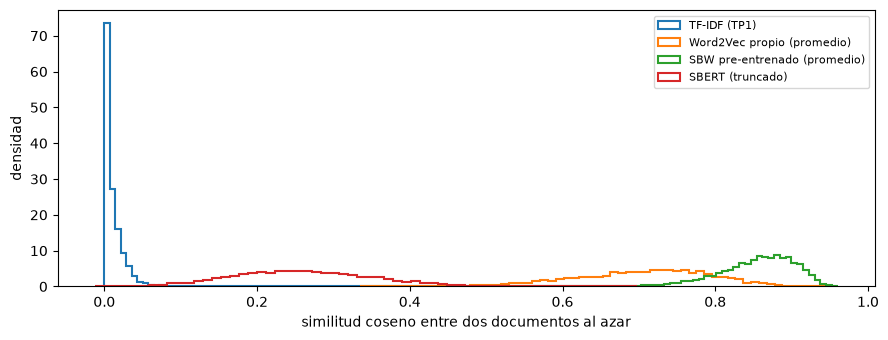

In [24]:
filas, muestras = [], {}
for clave, rep in reps.items():
    s = vectores.pares_aleatorios(rep.matriz, cantidad=5000, semilla=SEMILLA)
    muestras[rep.nombre] = s
    filas.append({"representación": rep.nombre, "media": s.mean(), "desvío": s.std(),
                  "mínimo": s.min(), "p5": np.percentile(s, 5),
                  "p95": np.percentile(s, 95), "máximo": s.max()})
tabla_pares = pd.DataFrame(filas).round(3)
display(tabla_pares)

fig, ax = plt.subplots(figsize=(9, 3.5))
for nombre in [reps[k].nombre for k in ["tfidf", "w2v", "sbw", "sbert"]]:
    ax.hist(muestras[nombre], bins=60, histtype="step", lw=1.5, label=nombre,
            density=True)
ax.set_xlabel("similitud coseno entre dos documentos al azar")
ax.set_ylabel("densidad"); ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(DIR_FIG / "similitudes_pares_aleatorios.png", dpi=120); plt.show()
tabla_pares.to_csv(RAIZ / "data" / "similitudes_pares_aleatorios.csv", index=False)

### Proyección 2D del corpus, coloreada por categoría

El color es la **categoría del sitio** por la que llegó cada libro: una etiqueta que ningún
modelo vio al construir los vectores. Los libros que llegaron por más de una categoría se
marcan como "varias".

**Advertencia metodológica.** PCA proyecta cientos de dimensiones sobre 2 y descarta casi
toda la varianza: abajo se informa cuánta explican PC1 + PC2. Una nube que se ve mezclada en
2D puede estar perfectamente separada en el espacio original, y una que se ve separada
puede deberse a una sola dirección dominante. La figura sirve para *intuir*, no para
concluir. La separación se mide en la sección 6.

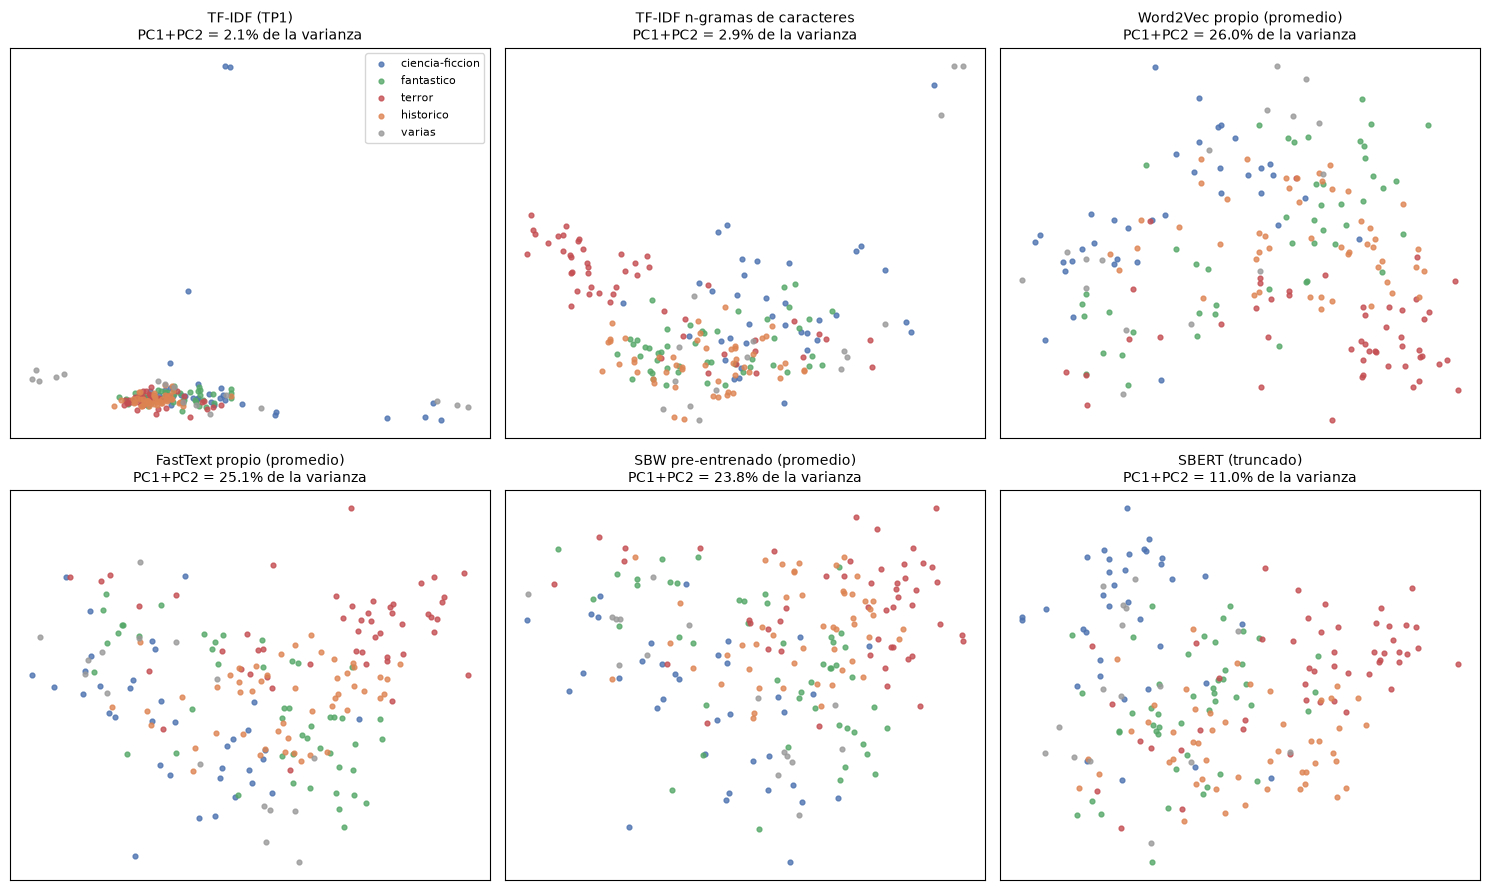

TF-IDF (TP1)                      2.1%
TF-IDF n-gramas de caracteres     2.9%
Word2Vec propio (promedio)       26.0%
FastText propio (promedio)       25.1%
SBW pre-entrenado (promedio)     23.8%
SBERT (truncado)                 11.0%
Name: varianza explicada por PC1+PC2, dtype: object

In [25]:
from sklearn.decomposition import PCA

etiqueta = np.array([d.categoria_origen[0] if len(d.categoria_origen) == 1 else "varias"
                     for d in docs])
colores = {"ciencia-ficcion": "#4C72B0", "fantastico": "#55A868", "terror": "#C44E52",
           "historico": "#DD8452", "varias": "#999999"}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
varianza = {}
for ax, clave in zip(axes.ravel(), ["tfidf", "tfidf_char", "w2v", "ft", "sbw", "sbert"]):
    rep = reps[clave]
    pca = PCA(n_components=2, random_state=SEMILLA)
    xy = pca.fit_transform(rep.matriz)
    var = pca.explained_variance_ratio_.sum()
    varianza[rep.nombre] = var
    for cat, col in colores.items():
        m = etiqueta == cat
        ax.scatter(xy[m, 0], xy[m, 1], s=12, c=col, label=cat, alpha=0.8)
    ax.set_title(f"{rep.nombre}\nPC1+PC2 = {var:.1%} de la varianza", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(DIR_FIG / "pca_por_categoria.png", dpi=120); plt.show()
pd.Series(varianza, name="varianza explicada por PC1+PC2").map("{:.1%}".format)

**t-SNE sobre SBERT.** t-SNE preserva vecindarios locales, no distancias globales. Se usa
`perplexity=30`, que es aproximadamente la cantidad de vecinos efectivos que considera cada
punto: con 200 documentos y grupos de ~50 por categoría, 30 es un valor intermedio
razonable (5 fragmentaría los grupos y 100 los fundiría). **No se pueden interpretar las
distancias entre clusters ni sus tamaños**: t-SNE expande las regiones densas y contrae las
dispersas, y dos clusters lejanos en la figura pueden no estarlo en el espacio original.

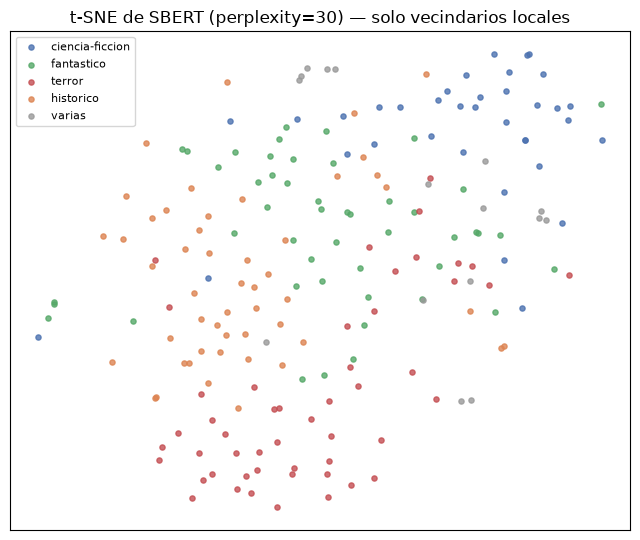

In [26]:
from sklearn.manifold import TSNE
xy = TSNE(n_components=2, perplexity=30, random_state=SEMILLA,
          init="pca").fit_transform(reps["sbert"].matriz)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for cat, col in colores.items():
    m = etiqueta == cat
    ax.scatter(xy[m, 0], xy[m, 1], s=14, c=col, label=cat, alpha=0.8)
ax.set_title("t-SNE de SBERT (perplexity=30) — solo vecindarios locales")
ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(DIR_FIG / "tsne_sbert.png", dpi=120); plt.show()

## 6. Evaluación (núcleo del TP)

Un buscador que devuelve resultados plausibles no está evaluado. Para cada consulta de
`queries.json` hay un conjunto de libros relevantes definido **a mano y antes de mirar los
resultados**. Con eso se calcula precision@k.

### Cómo se mide, y por qué así

- **precision@k** = relevantes entre los k primeros / k. El denominador es siempre k.
- **Empates.** Cuando varios documentos tienen el mismo puntaje (TF-IDF da 0 a todos los
  que no comparten palabras con la consulta), `argsort` los ordena por posición en el CSV y
  la precisión sale arbitraria. Se calcula la **precision@k esperada si los empates se
  rompen al azar**, de forma exacta (`evaluacion.precision_at_k`, con tests).
- **Piso de azar.** Elegir k libros al azar da en esperanza |R|/N por puesto. Es exacto, no
  hace falta simularlo. Es la línea de base que toda métrica necesita.
- **Techo.** Con 2 relevantes, P@5 no puede pasar de 0,4. Se informa junto a cada valor.
- **R-precision** (P@|R|): precisión con k = cantidad de relevantes. Su techo es 1 en todas
  las consultas, así que compensa el problema anterior.
- **Promedio macro**: cada consulta pesa lo mismo. Con 16 consultas el promedio se mueve
  mucho según cuáles se elijan, así que se informa un **intervalo bootstrap al 95 %**
  remuestreando consultas, y las comparaciones entre modelos se hacen **pareadas**,
  consulta por consulta.
- **Dudosos.** Los casos límite que el grupo marcó como dudosos se tratan como **no**
  relevantes. Aparte se informa la variante que sí los cuenta, para ver si alguna
  conclusión depende de esa decisión.

In [27]:
textos_por_id = dict(zip(ids, crudos))
filas = []
for c in consultas:
    sol = ev.solapamiento(c.texto, textos_por_id, c.relevantes, pp.tokenizar)
    filas.append({"id": c.id, "consulta": c.texto, "tipo": c.tipo,
                  "relevantes": len(c.relevantes), "dudosos": len(c.dudosos),
                  "piso": ev.piso_azar(len(c.relevantes), len(ids)),
                  "techo P@5": ev.techo(len(c.relevantes), 5),
                  "relevantes con palabras en común": sol["relevantes_con_solape"],
                  "distractores léxicos": len(sol["distractores"])})
tabla_consultas = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 55):
    display(tabla_consultas)

,id,consulta,tipo,relevantes,dudosos,piso,techo P@5,relevantes con palabras en común,distractores léxicos
0,q01,novelas de vampiros,tematica,6,1,0.030,1.0,1,12
1,q02,criaturas chupasangres que acechan de noche,sin_solapamiento,6,1,0.030,1.0,0,19
2,q03,historias de viajes en el tiempo,tematica,5,4,0.025,1.0,2,40
3,q04,extraterrestres que amenazan con invadir la Tierra,tematica,6,3,0.030,1.0,5,26
4,q05,historias de fantasmas y casas encantadas,tematica,9,5,0.045,1.0,5,18
5,q06,quiero leer algo que me dé miedo,amplia,54,0,0.270,1.0,4,5
6,q07,una historia de amor en la alta sociedad de la Ingl...,tematica,13,6,0.065,1.0,8,56
7,q08,novelas ambientadas en la Segunda Guerra Mundial,tematica,4,0,0.020,0.8,2,29
8,q09,novelas sobre la guerra civil española,tematica,2,1,0.010,0.4,1,32
9,q10,robots e inteligencias artificiales,tematica,6,3,0.030,1.0,0,2


### La consulta sin solapamiento léxico, verificada

La consigna pide al menos una consulta que no comparta **ninguna palabra** con sus
relevantes. Se verifica con la misma tokenización que usa TF-IDF: si la intersección es
vacía para todos los relevantes, su puntaje TF-IDF es **exactamente 0 por construcción**.

In [28]:
for c in consultas:
    if not c.sin_solapamiento:
        continue
    sol = ev.solapamiento(c.texto, textos_por_id, c.relevantes, pp.tokenizar)
    s = reps["tfidf"].puntajes(c.texto)
    puntaje_rel = [float(s[pos[i]]) for i in c.relevantes]
    assert sol["relevantes_con_solape"] == 0, sol["compartidos_por_relevante"]
    assert all(p == 0 for p in puntaje_rel)
    print(f"{c.id} «{c.texto}»")
    print(f"   tokens: {sol['tokens_consulta']}")
    print(f"   palabras compartidas con cada relevante: {sol['compartidos_por_relevante']}")
    print(f"   puntaje TF-IDF de los relevantes: {puntaje_rel}  -> 0 por construcción")
    print(f"   documentos NO relevantes que sí comparten palabras: {len(sol['distractores'])}")

q02 «criaturas chupasangres que acechan de noche»
   tokens: ['acechan', 'chupasangres', 'criaturas', 'noche']
   palabras compartidas con cada relevante: {125387: [], 125007: [], 125138: [], 125173: [], 125304: [], 124988: []}
   puntaje TF-IDF de los relevantes: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  -> 0 por construcción
   documentos NO relevantes que sí comparten palabras: 19
q12 «bucaneros, filibusteros y abordajes en el océano»
   tokens: ['abordajes', 'bucaneros', 'filibusteros', 'océano']
   palabras compartidas con cada relevante: {125216: [], 125274: []}
   puntaje TF-IDF de los relevantes: [0.0, 0.0]  -> 0 por construcción
   documentos NO relevantes que sí comparten palabras: 2
q13 «una epidemia que diezma a la población»
   tokens: ['diezma', 'epidemia', 'población']
   palabras compartidas con cada relevante: {125136: [], 125224: []}
   puntaje TF-IDF de los relevantes: [0.0, 0.0]  -> 0 por construcción
   documentos NO relevantes que sí comparten palabras: 1


### Palabras de la consulta que cada modelo de palabras conoce

Si un modelo no conoce ninguna palabra de la consulta, su vector es nulo y el ranking es
un empate total: rinde lo mismo que el azar, **por falta de vocabulario y no por falta de
semántica**. Es importante separar esos dos casos al interpretar.

In [29]:
filas = []
for c in consultas:
    fila = {"id": c.id, "consulta": c.texto}
    for nombre, kv in [("Word2Vec", w2v), ("SBW", sbw)]:
        cob = busqueda.cobertura_consulta(c.texto, kv)
        fila[f"{nombre}: desconocidas"] = ", ".join(cob["desconocidas"]) or "-"
        fila[f"{nombre}: vector nulo"] = not cob["conocidas"]
    filas.append(fila)
with pd.option_context("display.max_colwidth", 45):
    display(pd.DataFrame(filas))

,id,consulta,Word2Vec: desconocidas,Word2Vec: vector nulo,SBW: desconocidas,SBW: vector nulo
0,q01,novelas de vampiros,-,False,-,False
1,q02,criaturas chupasangres que acechan de noche,chupasangres,False,-,False
2,q03,historias de viajes en el tiempo,-,False,-,False
3,q04,extraterrestres que amenazan con invadir ...,-,False,-,False
4,q05,historias de fantasmas y casas encantadas,-,False,-,False
5,q06,quiero leer algo que me dé miedo,-,False,-,False
6,q07,una historia de amor en la alta sociedad ...,-,False,-,False
7,q08,novelas ambientadas en la Segunda Guerra ...,-,False,-,False
8,q09,novelas sobre la guerra civil española,-,False,-,False
9,q10,robots e inteligencias artificiales,-,False,-,False


### Resultados

In [30]:
buscadores = {rep.nombre: rep.puntajes for rep in reps.values()}
resultados = ev.evaluar(buscadores, consultas, ids, ks=(5, 10))
resultados.to_csv(RAIZ / "data" / "resultados_evaluacion.csv", index=False)

for k in (5, 10):
    print(f"\nprecision@{k} (media macro sobre {len(consultas)} consultas, IC bootstrap 95%)")
    display(ev.resumen(resultados, k).round(3))
print("\nR-precision (P@|R|)")
display(ev.resumen(resultados, 5, columna="r_precision").round(3))


precision@5 (media macro sobre 16 consultas, IC bootstrap 95%)


,modelo,p_at_k (media),IC95 bajo,IC95 alto,consultas
5,SBERT (truncado),0.363,0.225,0.513,16
6,SBERT (por fragmentos),0.363,0.225,0.513,16
1,TF-IDF n-gramas de caracteres,0.288,0.150,0.425,16
2,Word2Vec propio (promedio),0.200,0.088,0.338,16
3,FastText propio (promedio),0.200,0.112,0.288,16
0,TF-IDF (TP1),0.177,0.065,0.314,16
4,SBW pre-entrenado (promedio),0.163,0.088,0.238,16
7,AZAR (piso),0.041,0.021,0.075,16



precision@10 (media macro sobre 16 consultas, IC bootstrap 95%)


,modelo,p_at_k (media),IC95 bajo,IC95 alto,consultas
5,SBERT (truncado),0.250,0.150,0.350,16
6,SBERT (por fragmentos),0.225,0.150,0.300,16
1,TF-IDF n-gramas de caracteres,0.206,0.131,0.288,16
3,FastText propio (promedio),0.162,0.100,0.231,16
0,TF-IDF (TP1),0.160,0.088,0.242,16
2,Word2Vec propio (promedio),0.156,0.081,0.238,16
4,SBW pre-entrenado (promedio),0.138,0.075,0.219,16
7,AZAR (piso),0.041,0.021,0.075,16



R-precision (P@|R|)


,modelo,r_precision (media),IC95 bajo,IC95 alto,consultas
5,SBERT (truncado),0.379,0.222,0.548,16
1,TF-IDF n-gramas de caracteres,0.321,0.175,0.481,16
6,SBERT (por fragmentos),0.312,0.179,0.450,16
3,FastText propio (promedio),0.257,0.136,0.394,16
2,Word2Vec propio (promedio),0.251,0.119,0.411,16
0,TF-IDF (TP1),0.226,0.082,0.398,16
4,SBW pre-entrenado (promedio),0.212,0.099,0.355,16
7,AZAR (piso),0.041,0.021,0.075,16


In [31]:
print("precision@5 contando también los DUDOSOS como relevantes")
display(ev.resumen(resultados, 5, columna="p_at_k_amplia").round(3))

precision@5 contando también los DUDOSOS como relevantes


,modelo,p_at_k_amplia (media),IC95 bajo,IC95 alto,consultas
5,SBERT (truncado),0.475,0.325,0.625,16
6,SBERT (por fragmentos),0.438,0.312,0.575,16
1,TF-IDF n-gramas de caracteres,0.400,0.250,0.550,16
0,TF-IDF (TP1),0.290,0.168,0.428,16
3,FastText propio (promedio),0.275,0.188,0.363,16
2,Word2Vec propio (promedio),0.238,0.125,0.363,16
4,SBW pre-entrenado (promedio),0.225,0.138,0.312,16
7,AZAR (piso),0.051,0.028,0.085,16


### Consulta por consulta

Cada celda es la P@5 de un modelo en una consulta. Las últimas filas dan el piso de azar y
el techo de cada consulta, para leer cada número en su contexto.

In [32]:
p5 = resultados[resultados.k == 5]
tabla = p5.pivot(index="modelo", columns="consulta", values="p_at_k")
tabla = tabla.loc[[r.nombre for r in reps.values()] + ["AZAR (piso)"]]
techo_fila = p5.groupby("consulta").techo.first().rename("TECHO")
tabla = pd.concat([tabla, techo_fila.to_frame().T])
display(tabla.round(2).style.background_gradient(axis=None, cmap="Greens", vmin=0, vmax=1)
        .format("{:.2f}"))

consulta,q01,q02,q03,q04,q05,q06,q07,q08,q09,q10,q11,q12,q13,q14,q15,q16
TF-IDF (TP1),0.00,0.00,0.00,0.20,0.40,0.20,0.00,0.20,0.00,0.02,0.40,0.01,0.01,0.00,0.40,1.00
TF-IDF n-gramas de caracteres,0.80,0.40,0.00,0.20,0.40,0.60,0.00,0.20,0.00,0.20,0.60,0.00,0.00,0.00,0.40,0.80
Word2Vec propio (promedio),0.20,0.00,0.00,0.40,0.20,0.40,0.00,0.20,0.00,0.20,0.20,0.00,0.00,0.00,0.40,1.00
FastText propio (promedio),0.00,0.20,0.00,0.20,0.40,0.40,0.00,0.20,0.00,0.60,0.20,0.00,0.00,0.20,0.40,0.40
SBW pre-entrenado (promedio),0.00,0.40,0.00,0.20,0.20,0.40,0.00,0.00,0.00,0.20,0.00,0.00,0.20,0.40,0.40,0.20
SBERT (truncado),1.00,0.20,0.00,0.20,0.40,0.60,0.40,0.00,0.00,0.60,0.40,0.20,0.20,0.20,0.40,1.00
SBERT (por fragmentos),0.80,0.20,0.00,0.20,0.40,0.60,0.20,0.00,0.20,1.00,0.60,0.20,0.00,0.20,0.40,0.80
AZAR (piso),0.03,0.03,0.02,0.03,0.04,0.27,0.06,0.02,0.01,0.03,0.02,0.01,0.01,0.02,0.01,0.02
TECHO,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.80,0.40,1.00,0.80,0.40,0.40,1.00,0.40,1.00


In [33]:
print("Por tipo de consulta (P@5 media):")
display(p5.pivot_table(index="modelo", columns="tipo", values="p_at_k", aggfunc="mean")
          .loc[[r.nombre for r in reps.values()] + ["AZAR (piso)"]].round(3))

Por tipo de consulta (P@5 media):


tipo,amplia,lexica,sin_solapamiento,tematica
modelo,,,,
TF-IDF (TP1),0.20,0.700,0.005,0.122
TF-IDF n-gramas de caracteres,0.60,0.600,0.133,0.240
Word2Vec propio (promedio),0.40,0.700,0.000,0.140
FastText propio (promedio),0.40,0.400,0.067,0.180
SBW pre-entrenado (promedio),0.40,0.300,0.200,0.100
SBERT (truncado),0.60,0.700,0.200,0.320
SBERT (por fragmentos),0.60,0.600,0.133,0.360
AZAR (piso),0.27,0.018,0.017,0.030


### Comparación pareada contra la línea base TF-IDF

Consulta por consulta: en cuántas gana cada modelo, en cuántas empata y la diferencia media
con su intervalo bootstrap. Si el intervalo incluye el 0, con estas consultas no se puede
afirmar que un modelo sea mejor que el otro.

In [34]:
base = reps["tfidf"].nombre
filas = []
for rep in reps.values():
    if rep.nombre == base:
        continue
    r = ev.comparar_pareado(resultados, rep.nombre, base, 5)
    filas.append({"modelo": rep.nombre,
                  "gana": r["gana_" + rep.nombre], "empata": r["empatan"],
                  "pierde": r["gana_" + base],
                  "diferencia media P@5": r["diferencia_media"],
                  "IC95": f"[{r['IC95'][0]:+.3f}, {r['IC95'][1]:+.3f}]"})
pd.DataFrame(filas).round(3)

,modelo,gana,empata,pierde,diferencia media P@5,IC95
0,TF-IDF n-gramas de caracteres,5,8,3,0.110,"[+0.010, +0.235]"
1,Word2Vec propio (promedio),4,8,4,0.023,"[-0.038, +0.083]"
2,FastText propio (promedio),4,8,4,0.023,"[-0.090, +0.134]"
3,SBW pre-entrenado (promedio),5,6,5,-0.015,"[-0.164, +0.113]"
4,SBERT (truncado),8,7,1,0.185,"[+0.061, +0.335]"
5,SBERT (por fragmentos),9,4,3,0.185,"[+0.049, +0.346]"


### ¿Cuánta suerte puede tener el azar?

El piso es la *media* del azar. La dispersión importa: con pocos relevantes, un ranking al
azar a veces acierta. Se simulan 10.000 rankings al azar para la consulta amplia (`q06`,
54 relevantes) y para una estrecha.

In [35]:
for qid in ["q06", "q08"]:
    c = por_id[qid]
    rel = np.isin(ids, list(c.relevantes))
    sim = ev.simular_azar(rel, 5, repeticiones=10_000, semilla=SEMILLA)
    print(f"{qid} ({len(c.relevantes)} relevantes): P@5 del azar media {sim.mean():.3f} "
          f"(exacta {ev.piso_azar(len(c.relevantes), len(ids)):.3f}); "
          f"P(P@5 >= 0.4) = {(sim >= 0.4).mean():.1%}")

q06 (54 relevantes): P@5 del azar media 0.269 (exacta 0.270); P(P@5 >= 0.4) = 40.8%
q08 (4 relevantes): P@5 del azar media 0.019 (exacta 0.020); P(P@5 >= 0.4) = 0.3%


### Complemento: recuperar libros de la misma saga

Otra tarea, con relevancia que sale gratis de la columna `serie`: dado un libro, ¿en qué
puesto aparece otro tomo de su misma saga? Mide algo **distinto** de la búsqueda por
consulta. Recuperar "el mismo universo narrativo" premia los nombres propios compartidos,
que TF-IDF pondera al máximo, y no es lo que pide un usuario que describe un tema.
Advertencias: dos tomos de Norby tienen la sinopsis idéntica (un error del sitio), y los
modelos propios vieron estos textos al entrenar.

In [36]:
series = [d.serie for d in docs]
pd.DataFrame([{"representación": rep.nombre, **ev.mrr_misma_serie(rep.matriz, series)}
              for rep in reps.values()]).round(3)

,representación,mrr,acierto_1,acierto_5,evaluados
0,TF-IDF (TP1),0.881,0.835,0.924,79
1,TF-IDF n-gramas de caracteres,0.843,0.785,0.924,79
2,Word2Vec propio (promedio),0.780,0.684,0.899,79
3,FastText propio (promedio),0.712,0.595,0.848,79
4,SBW pre-entrenado (promedio),0.578,0.468,0.696,79
5,SBERT (truncado),0.828,0.785,0.886,79
6,SBERT (por fragmentos),0.804,0.747,0.861,79


**Por qué TF-IDF puede quedar *debajo* del azar.** En una consulta sin solapamiento, TF-IDF
da 0 a todos los relevantes. Si la consulta tampoco comparte palabras con *ningún*
documento, el ranking es un empate total y TF-IDF rinde exactamente el piso. Pero si
comparte palabras con documentos **no** relevantes (los "distractores léxicos" de la tabla
de consultas), esos quedan primero y empujan a los relevantes hacia abajo: el resultado
queda por debajo del azar. Es el caso de `q02`, con 19 distractores.

### Un caso concreto de fallo

Para la representación con mejor P@5 media se busca la consulta donde peor le fue, y se
muestra qué devolvió. Si dos representaciones empatan en la media, se toma la primera en el
orden de la tabla: SBERT truncado, que es el modelo de la consigna, va antes que la
variante por fragmentos.

In [37]:
orden_reps = [r.nombre for r in reps.values()]
medias = (p5[p5.modelo != "AZAR (piso)"].groupby("modelo").p_at_k.mean()
            .reindex(orden_reps))
mejor = medias.idxmax()          # ante empate, el primero en orden_reps
peor = p5[p5.modelo == mejor].sort_values(["p_at_k", "consulta"]).iloc[0]
c = por_id[peor.consulta]
rep = next(r for r in reps.values() if r.nombre == mejor)
print(f"Mejor representación: {mejor} (P@5 media {medias.max():.3f})")
print(f"Su peor consulta: {c.id} «{c.texto}» -> P@5 = {peor.p_at_k:.2f} "
      f"(piso {peor.piso:.3f}, techo {peor.techo:.1f})\n")
s = rep.puntajes(c.texto)
for i in rep.ranking(c.texto, 5):
    marca = "RELEVANTE" if ids[i] in c.relevantes else ("dudoso" if ids[i] in c.dudosos else "-")
    print(f"  {s[i]:.3f}  [{marca:<9}] {titulos[i]}  ({', '.join(docs[i].generos)})")

Mejor representación: SBERT (truncado) (P@5 media 0.362)
Su peor consulta: q03 «historias de viajes en el tiempo» -> P@5 = 0.00 (piso 0.025, techo 1.0)



  0.249  [-        ] La historia interminable (Ed. ilustrada)  (Aventuras, Fantástico, Infantil, Novela)
  0.225  [dudoso   ] Siete cuentos imposibles  (Fantástico, Relato)
  0.220  [-        ] Cuentos del antiguo Egipto  (Histórico, Juvenil, Relato)
  0.209  [-        ] Realidades a medida  (Ciencia ficción, Fantástico, Novela)
  0.203  [dudoso   ] Poshumanas y distópicas Vol. 1  (Ciencia ficción, Distopía, Relato)


**Diagnóstico.** Para formular una hipótesis con datos y no de memoria: en qué puesto
quedó cada relevante en cada representación, cuántos tokens tiene y si SBERT lo truncó. Si
los relevantes suben en la variante por fragmentos, lo que faltaba estaba en la parte
cortada. Si no suben, el problema es otro.

In [38]:
def puesto(rep, texto, idx):
    s = rep.puntajes(texto)
    return int((s > s[idx]).sum()) + 1          # puesto optimista ante empates

filas = []
for rid in sorted(c.relevantes):
    i = pos[rid]
    fila = {"relevante": titulos[i][:40], "tokens": int(trunc["largos"][i]),
            "truncado": bool(trunc["largos"][i] > sb.max_seq_length)}
    for clave in ["tfidf", "tfidf_char", "w2v", "sbw", "sbert", "sbert_frag"]:
        fila[reps[clave].nombre] = puesto(reps[clave], c.texto, i)
    filas.append(fila)
print(f"Puesto de cada relevante de {c.id} (de {len(ids)}):")
pd.DataFrame(filas)

Puesto de cada relevante de q03 (de 200):


,relevante,tokens,truncado,TF-IDF (TP1),TF-IDF n-gramas de caracteres,Word2Vec propio (promedio),SBW pre-entrenado (promedio),SBERT (truncado),SBERT (por fragmentos)
0,Los años del cuervo,167,True,43,99,188,109,75,107
1,Norby salva al universo,217,True,9,10,12,105,80,59
2,Buscando al Lobo de las Highlands,319,True,43,87,110,83,43,75
3,El pozo de la eternidad,182,True,43,127,96,160,16,24
4,El canto del cuerno,363,True,39,91,112,151,147,159


## Verificación de la ejecución

Comprueba que cada etapa produjo lo que tenía que producir. No alcanza con "la celda
corrió": se verifican condiciones concretas. Si alguna falla, la celda termina con error.

In [39]:
from importlib.util import find_spec
chequeos = []
def chequear(n, etapa, condicion, detalle=""):
    chequeos.append({"#": n, "etapa": etapa, "ok": "✓" if condicion else "✗ FALLA",
                     "detalle": detalle})

chequear(1, "Clonado del repositorio",
         (RAIZ / "src").exists() and (COMMIT != "(sin git)" or not EN_COLAB),
         f"commit {COMMIT}, rama {RAMA}" if EN_COLAB else f"commit {COMMIT} (local)")
chequear(2, "Dependencias", all(find_spec(m) for m in
         ["gensim", "sentence_transformers", "lingua", "sklearn", "torch"]),
         f"gensim {gensim.__version__}, st {sentence_transformers.__version__}")
chequear(3, "Corpus", len(docs) == 200 and len(docs_ampliado) == 1700,
         f"{len(docs)} libros + {len(docs_ampliado)} del ampliado")
chequear(4, "Modelos cargados", sbw.vector_size == 300 and len(sbw) > 0 and sb is not None,
         f"SBW {len(sbw):,} x {sbw.vector_size}; SBERT {busqueda.MODELO_SBERT}")
chequear(5, "Word2Vec entrenado", len(w2v) > 1000 and
         (RAIZ / "data" / "modelos" / "word2vec_libros_ampliado.model").exists(),
         f"{len(w2v):,} palabras, {embeddings.PARAMETROS['vector_size']} dims")
emb_ok = all(vectores.esta_normalizada(r.matriz) and not np.isnan(r.matriz).any()
             and (DIR_EMB / f"{k}.npy").exists() for k, r in reps.items())
chequear(6, "Embeddings (normalizados, sin NaN, en disco)", emb_ok,
         f"{len(reps)} representaciones")
chequear(7, "SBERT", busqueda.dimension_sbert(sb) == 512 and reps["sbert"].matriz.shape == (200, 512),
         f"dimensión {busqueda.dimension_sbert(sb)}, límite {sb.max_seq_length} tokens")
chequear(8, "Truncamiento", trunc["truncados"] == int((trunc["largos"] > sb.max_seq_length).sum()),
         f"{trunc['truncados']} de {trunc['documentos']} truncados")
r = reps["sbert"].ranking("un mundo de fantasía con dragones", 5)
chequear(9, "Búsquedas", len(set(r)) == 5, "ranking de 5 documentos distintos")
esperadas = (len(reps) + 1) * len(consultas) * 2
chequear(10, "Evaluación", len(resultados) == esperadas,
         f"{len(resultados)} filas = (modelos + azar) x {len(consultas)} consultas x 2 valores de k")
pk = resultados.p_at_k
chequear(11, "precision@k", pk.notna().all() and (pk >= 0).all()
         and (pk <= resultados.techo + 1e-9).all(), "sin NaN, entre 0 y el techo")
azar = resultados[resultados.modelo == "AZAR (piso)"]
chequear(12, "Baseline aleatorio", np.allclose(azar.p_at_k, azar.piso),
         f"piso medio P@5 {azar[azar.k == 5].p_at_k.mean():.3f}")
figuras = ["sbert_truncamiento", "similitudes_pares_aleatorios", "pca_por_categoria", "tsne_sbert"]
chequear(13, "Gráficos", all((DIR_FIG / f"{f}.png").exists() for f in figuras),
         f"{len(figuras)} figuras en data/figuras/")
mejor_final = ev.resumen(resultados, 5).iloc[0]
chequear(14, "Resultados finales", "PROVISIONAL" not in estado.upper(),
         f"mejor P@5: {mejor_final.modelo} ({mejor_final['p_at_k (media)']:.3f}); "
         f"consultas: {RUTA_CONSULTAS.name}")
salidas = [RAIZ / "data" / "resultados_evaluacion.csv",
           RAIZ / "data" / "similitudes_pares_aleatorios.csv", DIR_EMB / "ids.npy"]
chequear(15, "Outputs guardados", all(p.exists() for p in salidas),
         "resultados, similitudes, embeddings y figuras en data/")

tabla_chequeos = pd.DataFrame(chequeos).set_index("#")
display(tabla_chequeos)
fallas = tabla_chequeos[tabla_chequeos.ok != "✓"]
if len(fallas):
    print(f"\n{len(fallas)} chequeo(s) no pasaron: {list(fallas.etapa)}")
    if list(fallas.index) == [14]:
        print("Solo falla el 14: el conjunto de evaluación sigue siendo PROVISIONAL.")
    else:
        raise AssertionError("La ejecución no está completa: ver la tabla.")
else:
    print("\nTodas las etapas verificadas.")

,etapa,ok,detalle
#,,,
1,Clonado del repositorio,✓,commit (sin git) (local)
2,Dependencias,✓,"gensim 4.4.0, st 6.1.0"
3,Corpus,✓,200 libros + 1700 del ampliado
4,Modelos cargados,✓,"SBW 400,000 x 300; SBERT distiluse-base-multilingual-cas..."
5,Word2Vec entrenado,✓,"8,617 palabras, 100 dims"
6,"Embeddings (normalizados, sin NaN, en disco)",✓,7 representaciones
7,SBERT,✓,"dimensión 512, límite 128 tokens"
8,Truncamiento,✓,172 de 200 truncados
9,Búsquedas,✓,ranking de 5 documentos distintos



1 chequeo(s) no pasaron: ['Resultados finales']
Solo falla el 14: el conjunto de evaluación sigue siendo PROVISIONAL.


## 7. Conclusiones

> **Pendiente.** Esta sección se escribe con los números de la evaluación **definitiva**,
> una vez que el grupo valide `queries.json`. Mientras el conjunto sea provisional, ninguna
> conclusión de la sección 6 es definitiva.